In [117]:
import numpy as np
import matplotlib.pyplot as plt

In [118]:
file_path = "../outputs/"

# Analysis Excercise 02.1

### Montecarlo estimation of an integral: uniform and importance sampling

In this excercise we aim to evaluate an integral

$$I = \int_a^b f(x) dx$$

via Monte Carlo methods.

The estimator for the integral is the quantity

$$(b-a)\langle g \rangle = (b-a)\frac{1}{N}\sum_{i=1}^Ng(x_i)$$

where the $x_i$ are extracted from a distribution $p(x)$, such that $g(x)p(x)=f(x)$, and $N$ is the number of variables extracted. The Central Limit Theorem assures that the estimator converges to the true value of the integral.

In general every $p(x)$ is suitable for the calculation of the integral, but not equivalently efficient: the more the probability distribution is similar to the integrand function, the smaller is the error on the estimation of the integral at fixed $N$. In general the best $p(x)$ would be the normalized module of the integrand, that would imply knowing the value of the integral, which is exactly what we aim to obtain. The strategy is, therefore, to find a probability distribution $d(x)$ that resembles the integrand function and refactor the integal like


$$I = \int_a^b \frac{g(x)p(x)}{d(x)}d(x) dx$$

and extract the $x_i$ according to the distribution $d(x)$ evaluating the function $\frac{g(x)p(x)}{d(x)}$.

The evaluation method based on the sampling according to a distribution similar to the integrand will be referred to as $\textit{importance sampling}$ in the following.

For this exercise the integral to evaluate is

$$I = \int_a^b \frac{\pi}{2}\cos\left(\frac{\pi}{2}x\right) dx$$

At first I evaluated the integral sampling the $x_i$ from a uniform density distribution.

To implement the importance sampling method, I decided to use the normalised first order Taylor expansion of the integrand around $x=1$. Taking a look at the derivatives of the integrand function

$$f^{\prime}(x) = -\frac{\pi^2}{4} \sin\left(\frac{\pi}{2}x\right)$$
$$f^{\prime\prime} = -\frac{\pi^3}{8} \cos\left(\frac{\pi}{2}x\right)$$

one notices that expanding around $x=0$ the Taylor expansion to the first non null order of the integrand would be

$$d(x) = \mathcal{N} \left(\frac{\pi}{2} - \frac{\pi^3}{16}x^2\right)$$

where $\mathcal{N}$ is the normalization constant for $d(x)$ should be a probability distribution: this choice holds a problem, that is that for $x=1$ $d(x)$ is negative, therefore it is not a good probability distribution for the solution of our problem.

The choice of expanding around $x=1$ gives a normalized probability distribution

$$d(x) = 2(1-x)\chi_{[0,1]}$$
which is positive for all values $x \in [0, 1]$. The function to evaluate is

$$f(x) = \frac{\pi}{4}\frac{\cos\left(\frac{\pi}{2}x\right)}{1-x}$$

In order to extract values according to the distribution $d(x)$ I chose to use the inverse transform method. The cumulative function is

$$F(x) = \int_0^x 2(1-x^{\prime}) dx^{\prime} = 2\left(x-\frac{x^2}{2}\right)$$

which is not globally invertible, but can be inverted locally in the interval $[0, 1]$. The inversion gives the law

$$x(r) = 1-\sqrt{1-r}$$

where $r$ is a number uniformly distributed in $[0, 1)$. Below one can see that the distribution of the number extracted with this method is the expected one.

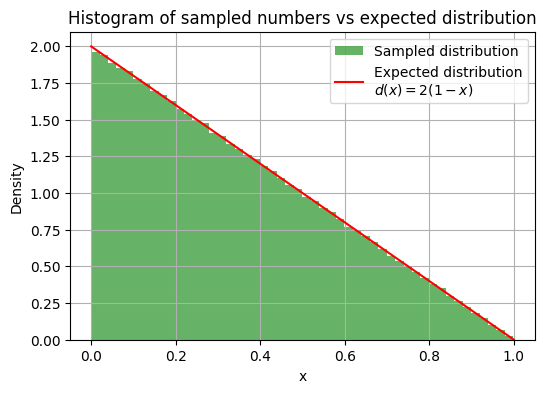

In [144]:
np.random.seed(42)
random_numbers = np.random.uniform(0, 1, size=1000000)

x = 1-np.sqrt(1-random_numbers)

plt.figure(figsize=(6, 4))

# density=True to normalize the histogram and compare it with the expected distribution
plt.hist(x, bins=50, density=True, alpha=0.6, color='g', label='Sampled distribution') 

plt.plot(np.linspace(0, 1, 100), 2*(1-np.linspace(0, 1, 100)), 'r-', label='Expected distribution\n$d(x) = 2(1-x)$')

plt.xlabel('x')
plt.ylabel('Density')
plt.title('Histogram of sampled numbers vs expected distribution')
plt.legend()
plt.grid(True)
plt.show()

The expected result is that the evaluation with the importance sampling reduces the variance on the value on the integral, and therefore leads to a smaller standard deviation with respect to the uniform sampling.

### Estimation of the integral

In [145]:
x, estimate_prog_unif, err_prog_unif, estimate_prog_importance, erro_prog_importance = np.loadtxt(file_path + "02_1_integral.dat", unpack=True)

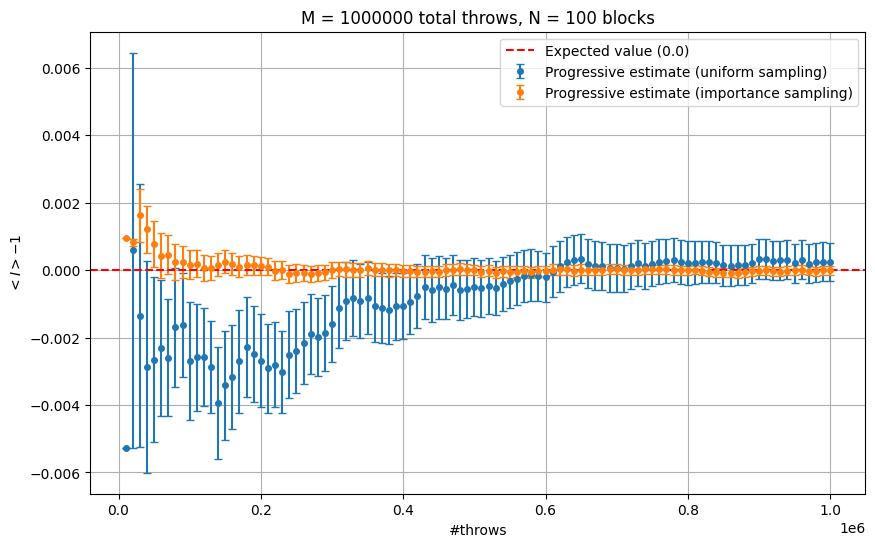

In [146]:
plt.figure(figsize=(10, 6))

plt.errorbar(x, estimate_prog_unif - 1, yerr=err_prog_unif, label = 'Progressive estimate (uniform sampling)', fmt='o', markersize=4, capsize=3)
plt.errorbar(x, estimate_prog_importance - 1, yerr=erro_prog_importance, label = 'Progressive estimate (importance sampling)', fmt='o', markersize=4, capsize=3)
plt.axhline(0, color='red', linestyle='--', label='Expected value (0.0)')
plt.xlabel('#throws')
plt.ylabel('$<I> - 1$')
plt.title('M = {} total throws, N = {} blocks'.format(int(x[-1]), int(len(x))))
plt.grid(True)
plt.legend()
plt.show()

In [147]:
mean_final_estimate_unif = estimate_prog_unif[-1]
mean_final_error_unif = err_prog_unif[-1]
print(f"===== Final estimation of the integral (uniform sampling): {mean_final_estimate_unif:.4f} ± {mean_final_error_unif:.4f} =====")

mean_final_estimate_importance = estimate_prog_importance[-1]
mean_final_error_importance = erro_prog_importance[-1]
print(f"===== Final estimation of the integral (importance sampling): {mean_final_estimate_importance:.4f} ± {mean_final_error_importance:.4f} =====")

===== Final estimation of the integral (uniform sampling): 1.0002 ± 0.0006 =====
===== Final estimation of the integral (importance sampling): 1.0000 ± 0.0001 =====


As expected the error at fixed $N$ is smaller with the importance sampling method.

# Analysis Excercise 02.2

In the following exercise we aim to analyze the dependence of the mean squared root of a $3D$ Random Walk (RW) process $\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}}$ with the number of steps $N$. We analyze this dependence first with a RW defined on a cubic lattice and then on one with spherical symmetry.

A RW is a stochastic process in whic a walker, a point in the $d$ - dimensional space, moves in the space. In this case we consider a discrete time RW with fixed step length $a=1$. The important property of a RW is that it is a Markovian Process: the probability for the walker to be in a point $x_t$ at a time $t$ only depends on the position $x_{t-1}$ at time $t-1$ and not on the rest of the history of the walker.

In this exercise we consider the case of the directions being all equally probable: this defines a $\textit{Universlity Class}$. The universality is given by the fact that if one evaluates the root mean squared displacement after $N$ steps, one finds a dependence

$$\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}} = a\sqrt{N}$$

In the cubic lattice the walker can move one step at a time along one of three orthogonal directions forward ($+1$) or backwards ($-1$).



In [149]:
x, rw_lattice, var1, rw_cont, var2 = np.loadtxt(file_path + "02_2_RW.dat", unpack=True)

Fitted parameter: k = 1.0004


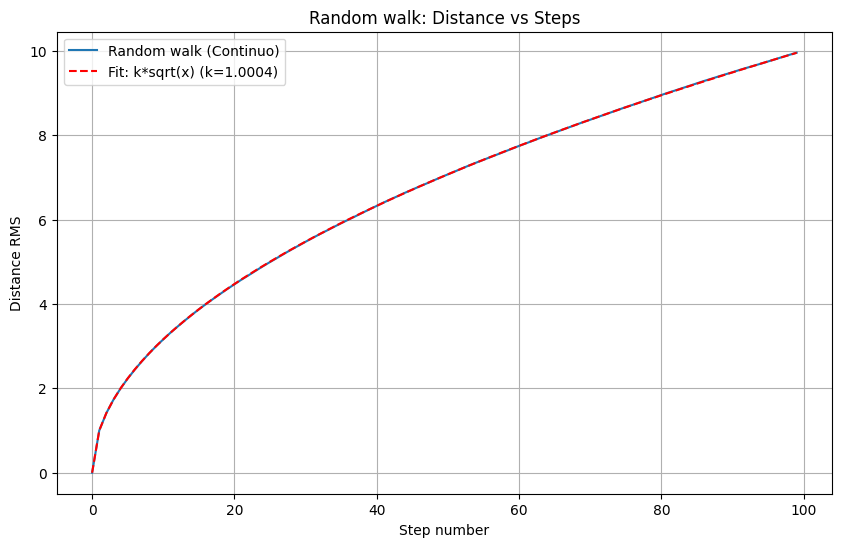

In [150]:
x, rw_lattice, var1, rw_cont, var2 = np.loadtxt(file_path + "02_2_RW.dat", unpack=True)

from scipy.optimize import curve_fit
import numpy as np

# Funzione suggerita dal professore: f(N) = k * sqrt(N)
def fit_func(x, k):
    return k * np.sqrt(x)

# Fit (usiamo rw_cont assumendo sia l'array dei tuoi dati continui)
params, covariance = curve_fit(fit_func, x, rw_lattice)
k_fit = params[0]

print(f"Fitted parameter: k = {k_fit:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(x, rw_lattice, label='Random walk (Continuo)')
plt.plot(x, fit_func(x, k_fit), 'r--', label=f'Fit: k*sqrt(x) (k={k_fit:.4f})')
plt.xlabel('Step number')
plt.ylabel('Distance RMS')
plt.title('Random walk: Distance vs Steps')
plt.grid(True)
plt.legend()
plt.show()

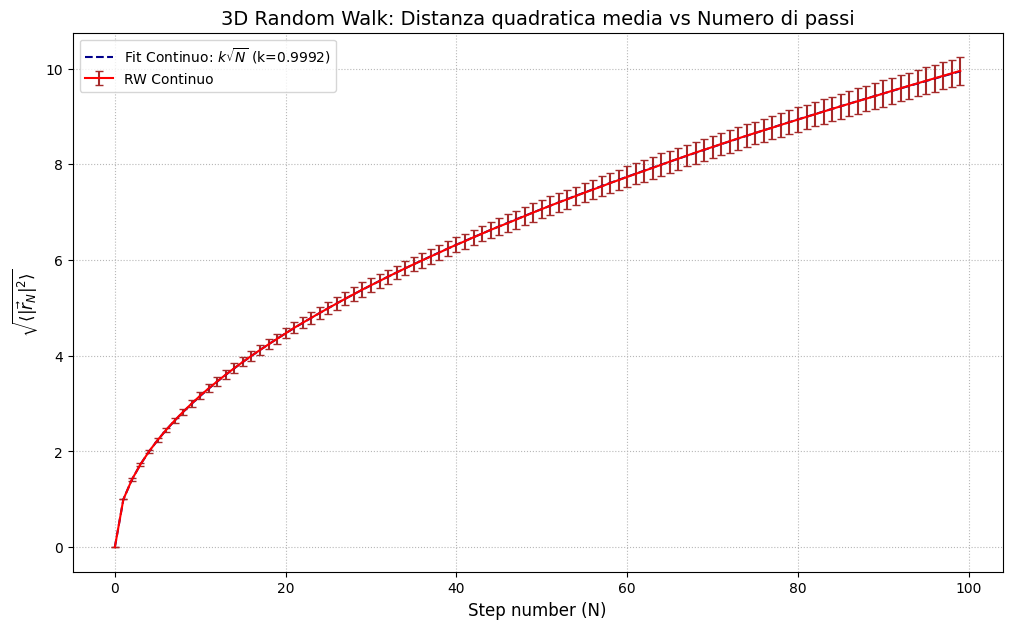

In [152]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# 1. Caricamento dei dati
# (Usa il tuo path corretto se il file è in un'altra cartella)
x, rw_lattice, err_lattice, rw_cont, err_cont = np.loadtxt(file_path+"02_2_RW.dat", unpack=True)

# 2. Definizione della funzione di fit (f(N) = k * sqrt(N))
def fit_func(x, k):
    return k * np.sqrt(x)

# 3. Calcolo dei fit per entrambi i Random Walk
params_cont, _ = curve_fit(fit_func, x, rw_cont)
k_cont = params_cont[0]

params_lat, _ = curve_fit(fit_func, x, rw_lattice)
k_lat = params_lat[0]

# 4. Creazione del grafico
plt.figure(figsize=(12, 7))

# Plot del RW nel Continuo con barre d'errore
# fmt='-' unisce i punti con una linea, capsize imposta la larghezza delle stanghette dell'errore
plt.errorbar(x, rw_cont, yerr=20*err_cont, label='RW Continuo', fmt='-', color='red', ecolor='brown', capsize=3)
plt.plot(x, fit_func(x, k_cont), color='darkblue', linestyle='--', label=f'Fit Continuo: $k\\sqrt{{N}}$ (k={k_cont:.4f})')

# Personalizzazione del grafico
plt.xlabel('Step number (N)', fontsize=12)
plt.ylabel(r'$\sqrt{\langle |\vec{r}_N|^2 \rangle}$', fontsize=12)
plt.title('3D Random Walk: Distanza quadratica media vs Numero di passi', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.9)

# Mostra il grafico
plt.show()

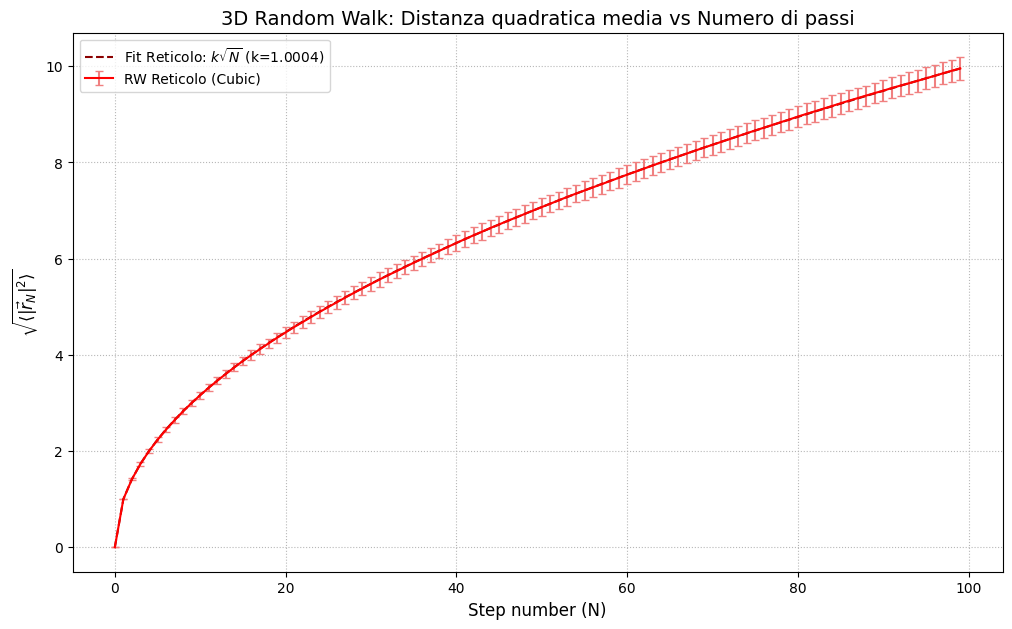

In [153]:
plt.figure(figsize=(12, 7))

# Plot del RW sul Reticolo (Lattice) con barre d'errore
plt.errorbar(x, rw_lattice, yerr=20*err_lattice, label='RW Reticolo (Cubic)', fmt='-', color='red', ecolor='lightcoral', capsize=3)
plt.plot(x, fit_func(x, k_lat), color='darkred', linestyle='--', label=f'Fit Reticolo: $k\\sqrt{{N}}$ (k={k_lat:.4f})')

# Personalizzazione del grafico
plt.xlabel('Step number (N)', fontsize=12)
plt.ylabel(r'$\sqrt{\langle |\vec{r}_N|^2 \rangle}$', fontsize=12)
plt.title('3D Random Walk: Distanza quadratica media vs Numero di passi', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.9)

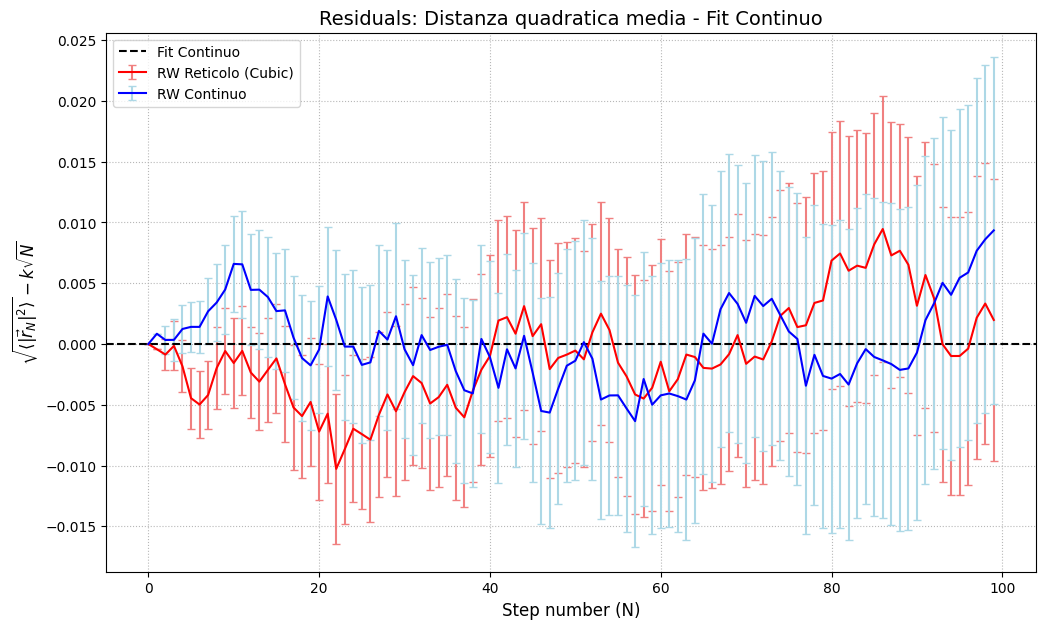

In [156]:
plt.figure(figsize=(12, 7))

plt.errorbar(x, rw_lattice - fit_func(x, k_lat), yerr=err_lattice, label='RW Reticolo (Cubic)', fmt='-', color='red', ecolor='lightcoral', capsize=3)
plt.errorbar(x, rw_cont - fit_func(x, k_cont), yerr=err_cont, label='RW Continuo', fmt='-', color='blue', ecolor='lightblue', capsize=3)
plt.axhline(0, color='black', linestyle='--', label='Fit Continuo')
plt.xlabel('Step number (N)', fontsize=12)
plt.ylabel(r'$\sqrt{\langle |\vec{r}_N|^2 \rangle} - k\sqrt{N}$', fontsize=12)
plt.title('Residuals: Distanza quadratica media - Fit Continuo', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.9)
plt.show()

Alla fine voglio ottenere un grafico della radice del valor medio di r^2 in funzione del numero di passi con la sua incertezza. Quindi io itero sui blocchi. Dentro ogni blocco faccio partire i random walk: per il primo random walk salvo il modulo quadro della posizione a ogni step. Al random walk successivo sommo il modulo quadro della posizione a ciascuno step e così via. Ottengo dei vettori di dimensione nstep che contengono in ciascun elemento la somma dei moduli quadri delle posizioni dei vari random walk a ciasuno step. Alla fine del blocco divido ciascuno degli elementi per il numero di random walk. Poi faccio la radice quadrata di ciascuno degli elementi.

Adesso devo mediare questa quantità sui blocchi. Quindi alla fine di ogni blocco sommo ciascuno degli elementi di r_squared_lattice_final con il corrispondente elemento di r_squared_lattice e così via. Alla fine di tutti i blocchi divido ciascuno degli elementi di r_squared_lattice_final per N, in modo da ottenere il valor medio di r^2 sotto radice a ciascun step, mediato su tutti i blocchi.